In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import ast
import seaborn as sns
sns.set_style("whitegrid")
import shapely as shapely
from shapely.geometry import LineString
import scipy.special as sc
from numba_stats import norm, binom
from mpl_toolkits.axes_grid1 import make_axes_locatable
from iminuit import cost, Minuit
import scipy.integrate as integrate

In [3]:
def SingleEscapeSort(dataframe):
    dataframe = dataframe.drop('Unnamed: 0', axis=1)
    # if b==True:
    #     dataframe = dataframe.drop('10', axis=1)
    col = dataframe.pop("NTD")
    col2 = dataframe.pop('EnergyV')
    col3 = dataframe.pop('ChannelV')
    col4 = dataframe.pop('Neighbors')
    dataframe.insert(9, col2.name, col2)
    dataframe.insert(15, col.name, col)
    dataframe.insert(10, col3.name, col3)
    dataframe.insert(14, col4.name, col4)
    
    dataframe3 = dataframe[(dataframe['Multiplicity'] == 2)]
    dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
    dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
    dataframe3['NTD']=dataframe3['NTD'].apply(ast.literal_eval)
    dataframe3['Neighbors']=dataframe3['Neighbors'].apply(ast.literal_eval)
    
    rid3 = []
    dataframe3=dataframe3.reset_index(drop=True)
    for i in range(len(dataframe3)):
        if (2080<= dataframe3.iloc[i,9][1]< 2120):
            rid3.append(i)
            
    dataframe3_2100 = dataframe3[dataframe3.index.isin(rid3)]
    dataframe3_2100=dataframe3_2100.reset_index(drop=True)
    
    return dataframe3_2100

def NTD_Sort(dataframe_1tonne_single):
    NTD_data = []
    no_NTD_data = []

    NTD_data = []

    for i in range(len(dataframe_1tonne_single)):
        if (dataframe_1tonne_single.iloc[i,10][0] in dataframe_1tonne_single.iloc[i,17]) or (dataframe_1tonne_single.iloc[i,10][1] in dataframe_1tonne_single.iloc[i,17]):
            NTD_data.append(i) 
        else:
            no_NTD_data.append(i)

    NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(NTD_data)]
    NTD_data=NTD_data.reset_index(drop=True)

    # for i in range(len(dataframe_1tonne_single)):
    #     for j in range(len(dataframe_1tonne_single.iloc[i,10])):
    #         if dataframe_1tonne_single.iloc[i,10][0] and dataframe_1tonne_single.iloc[i,10][1] not in dataframe_1tonne_single.iloc[i,17]:
    #             no_NTD_data.append(i) 

    no_NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(no_NTD_data)]
    no_NTD_data=no_NTD_data.reset_index(drop=True)
    
    return NTD_data, no_NTD_data

def Topology_Sort(no_NTD_data):
    F_NTD = []
    E_NTD = []
    N_NTD = []
    C_NTD = []
    O_NTD = []
    for i in range(len(no_NTD_data)):
        if no_NTD_data.iloc[i,14][0][0] == 'F':
            F_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'E':
            E_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'N':
            N_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'C':
            C_NTD.append(i)
        else:
            O_NTD.append(i)
            
    F_NTD = no_NTD_data[no_NTD_data.index.isin(F_NTD)]
    F_NTD=F_NTD.reset_index(drop=True)
    
    E_NTD = no_NTD_data[no_NTD_data.index.isin(E_NTD)]
    E_NTD=E_NTD.reset_index(drop=True)
    
    N_NTD = no_NTD_data[no_NTD_data.index.isin(N_NTD)]
    N_NTD=N_NTD.reset_index(drop=True)
    
    C_NTD = no_NTD_data[no_NTD_data.index.isin(C_NTD)]
    C_NTD=C_NTD.reset_index(drop=True)
    
    return F_NTD, E_NTD, C_NTD, N_NTD

def PrimarySecondarySplit(dataframe_1tonne_double):
    total_2100 = []
    total_511 = []

    for i in range(len(dataframe_1tonne_double)):
        total_511.append(dataframe_1tonne_double.iloc[i,9][0])
        total_2100.append(dataframe_1tonne_double.iloc[i,9][1])
        
    return np.asarray(total_2100), np.asarray(total_511)

In [4]:
def ChannelRemoval(dataframe):
    df = pd.read_csv('InvalidChannels/M2SE511_InvalidChannelList.csv', sep=',')
    datasetlist = np.arange(3801, 3829)

    # Create a dictionary mapping each dataset to its channel list
    channel_map = df.groupby('Dataset')['Channels'].apply(list).to_dict()

    channel = []

    # Loop through the filtered datasets in dataframe_single
    for i in datasetlist:
        # Get the channel list for the dataset from the pre-built dictionary
        channel_list = channel_map.get(i, [])
        
        # Filter only rows in dataframe_single where the 'Dataset' equals the current dataset
        relevant_rows = dataframe[dataframe['Dataset'] == i]
        
        # Check for channel matches using vectorized apply with any()
        matches = relevant_rows.index[
            relevant_rows.iloc[:, 10].apply(lambda x: any(ch in channel_list for ch in x))
        ].tolist()
        
        # Add matching indices to the channel list
        channel.extend(matches)
        
    dataframe_reduced = dataframe.drop(channel)
    dataframe_reduced=dataframe_reduced.reset_index(drop=True)
        
    return dataframe_reduced

In [5]:
dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
dataframe_single = SingleEscapeSort(dataframe)

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_40093/3691485836.py:1: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_40093/3628271106.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_40093/3628271106.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documenta

In [6]:
dataframe_reduced_single = ChannelRemoval(dataframe_single)

In [7]:
NTD_single, no_NTD_single = NTD_Sort(dataframe_reduced_single)
F_NTD, E_NTD, C_NTD, N_NTD= Topology_Sort(NTD_single)
F, E, C, N= Topology_Sort(no_NTD_single)

NTD_2100, NTD_511 = PrimarySecondarySplit(NTD_single)
noNTD_2100, noNTD_511 = PrimarySecondarySplit(no_NTD_single)

In [7]:
print(len(dataframe_single))
print(len(dataframe_reduced_single))

142695
132755


In [8]:
# def TailFunc(x, mu, sigma, beta,f):
#     z = np.sqrt(beta**2/(2*sigma**2))*(sigma**2/beta**2-(x-mu)/beta)
    
#     tail = np.sqrt(np.exp(sigma**2/beta**2)/(4*beta**2))*np.exp(-(x-mu)/beta)*sc.erfc(z)

#     return f*tail+(1-f)*norm.pdf(x,mu,sigma)
#     # return tail

# def Triple_Gaussian(x, mu, mu2,mu3, sigma,sigma3, p1,p2, c1, c2, c3):
#     E1=max(x)
#     E0=min(x)
    
#     Ec = (E1+E0)/2
#     DE = (E1-E0)/2
    
#     norm_poly = 2*DE+(2/3)*p2*DE**3
#     poly = (1+p1*(x-Ec)+p2*(x-Ec)**2)/norm_poly
    
#     step = sc.erfc((x-mu)/(np.sqrt(2)*sigma))
#     step_const = (mu-E0)*sc.erfc((E0-mu)/(np.sqrt(2)*sigma))+(E1-mu)*sc.erfc((E1-mu)/(np.sqrt(2)*sigma))+np.sqrt(2/np.pi)*sigma*(np.exp(-(mu-E0)**2/(2*sigma**2))-np.exp(-(mu-E1)**2/(2*sigma**2)))
    
#     return (1-c1-c2-c3)*norm.pdf(x,mu, sigma)+c1*norm.pdf(x,mu2, sigma)+c3*norm.pdf(x,mu3, sigma3)+c2*poly

def Triple_Gaussian(x, mu, mu2,mu3, sigma,sigma3, A, c1, c2, c3):
    E0 = min(x)
    E1=max(x)
    Ec = (E0+E1)/2
    p = (1+A*(x-Ec))/(E1-E0)
    return (1-c1-c2-c3)*norm.pdf(x,mu,sigma)+c2*norm.pdf(x,mu2, sigma)+c3*norm.pdf(x,mu3,sigma3)+c1*p

def Chi2(data, arr, bin_num):
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]

    fitted_pdf = Triple_Gaussian(filtered_bin_centers, *arr)*len(data)*bin_width

    chi2 = np.sum((filtered_hist-fitted_pdf)**2/fitted_pdf)
    
    return chi2

def PValue(dof, chi2):
    return 1-(sc.gammainc(dof/2, chi2/2))

def Residual_Plot(data, arr, bin_num):
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]

    fitted_pdf = Triple_Gaussian(filtered_bin_centers, *arr)*len(data)*bin_width
    
    return filtered_bin_centers, (filtered_hist - fitted_pdf)/np.sqrt(filtered_hist), np.sqrt(filtered_hist)

def Minimizer(data, title, initial_parms, bin_num):
    E1=max(data)
    E0=min(data)
    
    Ec = (E1+E0)/2
    DE = (E1-E0)/2
    bound_A = 1/(Ec-E0)
    
    c = cost.UnbinnedNLL(data, Triple_Gaussian)

    m = Minuit(c,*initial_parms)
    m.limits['c1', 'c2', 'c3'] = (0, 1)
    m.limits['mu','sigma', 'mu2', 'mu3', 'sigma3'] = (0, None)
    m.limits["A"] = (-bound_A, bound_A)
    m.migrad()
    m.hesse()

    x_values = np.linspace(min(data), max(data), 1000)
    bin_width = (max(data) - min(data))/bin_num

    fig = plt.figure()
    ax=fig.add_axes((.1,.3,.8,.6))
    
    props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.5)
    text = '\n'.join(( r'$\Delta\chi^2/ndf= $' + str(np.round(Chi2(data, m.values, bin_num), decimals=2)) +'/' +str(bin_num - (Triple_Gaussian.__code__.co_argcount -1), ),
                    r'$P(ndf,\chi^2)=%.2f$' % (PValue(bin_num - (Triple_Gaussian.__code__.co_argcount -1),Chi2(data, m.values, bin_num)), ),
        'Entries: ' + (str(len(data))),
        r'$\mu=$ ' + str(np.round(m.values[0], decimals = 2) ) + '+-'+ str(np.round(m.errors[0], decimals = 2) ),
        r'$\mu_2=$ ' + str(np.round(m.values[1], decimals = 2) ) + '+-'+ str(np.round(m.errors[1], decimals = 2) ),
        r'$\mu_3=$ ' + str(np.round(m.values[2], decimals = 2) ) + '+-'+ str(np.round(m.errors[2], decimals = 2) ),
        r'$\sigma=$ ' + str(np.round(m.values[3], decimals = 2) ) + '+-'+ str(np.round(m.errors[3], decimals = 2) ),
        #r'$\sigma_2=$ ' + str(np.round(m.values[4], decimals = 2) ) + '+-'+ str(np.round(m.errors[3], decimals = 2) ),
        r'$\sigma_3=$ ' + str(np.round(m.values[4], decimals = 2) ) + '+-'+ str(np.round(m.errors[4], decimals = 2) ),
        r'$A=$ ' + str(np.format_float_scientific(m.values[5], precision = 2) ) + '+-'+ str(np.format_float_scientific(m.errors[5], precision = 2) ),
        #r'$p_2=$ ' + str(np.format_float_scientific(m.values[6], precision = 2) ) + '+-'+ str(np.format_float_scientific(m.errors[6], precision = 2) ),
        r'$c_1=$ ' + str(np.format_float_scientific(m.values[6], precision = 2) ) + '+-'+ str(np.format_float_scientific(m.errors[6], precision = 2) ),
        r'$c_2=$ ' + str(np.format_float_scientific(m.values[7], precision = 2) ) + '+-'+ str(np.format_float_scientific(m.errors[7], precision = 2) ),
        r'$c_3=$ ' + str(np.format_float_scientific(m.values[8], precision = 2) ) + '+-'+ str(np.format_float_scientific(m.errors[8], precision = 2) )
        ))
    
    mu,mu2, mu3, sigma, sigma3, A, c1,c2, c3 = m.values
    mu_err,mu2_err, mu3_err, sigma_err, sigma3_err, Aerr,c1_err,c2_err, c3_err = m.errors

    ax.hist(data, bins = bin_num , histtype='step');
    ax.plot(x_values, Triple_Gaussian(x_values,*m.values)*len(data)*bin_width,label='Fitted PDF', color='#000272')
    ax.plot(x_values, (1-c1-c2-c3)*norm.pdf(x_values,mu, sigma)*len(data)*bin_width, label='Gaussian 1', linestyle='--', color='#A72693')
    ax.plot(x_values, c2*norm.pdf(x_values,mu2, sigma)*len(data)*bin_width, label='Gaussian 2', linestyle='--', color='#02383C')
    ax.plot(x_values, c3*norm.pdf(x_values,mu3,sigma3)*len(data)*bin_width, label='Gaussian 3', linestyle='--', color='#BD512F')
    ax.plot(x_values, c1*((1+A*(x_values-Ec))/(E1-E0))*len(data)*bin_width, label='Linear Bckg', linestyle='--', color='#615DEC')
    # ax.plot(x_values, (sc.erfc((x_values-mu)/(np.sqrt(2)*sigma)))/((mu-E0)*sc.erfc((E0-mu)/(np.sqrt(2)*sigma))+(E1-mu)*sc.erfc((E1-mu)/(np.sqrt(2)*sigma))+np.sqrt(2/np.pi)*sigma*(np.exp(-(mu-E0)**2/(2*sigma**2))-np.exp(-(mu-E1)**2/(2*sigma**2))))*len(data)*bin_width, linestyle='--', label='Step Func')
    ax.legend(loc='upper right')
    ax.text(0.03, 0.95, text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)
    ax.set_title(title)

    ax2=fig.add_axes((.1,.08,.8,.2))        
    ax2.errorbar(Residual_Plot(data, m.values, bin_num)[0],Residual_Plot(data, m.values, bin_num)[1], fmt='o',markersize=4)
    ax2.axhline(0, linestyle='--', color='crimson')
    
    return mu, mu_err, mu2, mu2_err, mu3, mu3_err, sigma, sigma_err, sigma3, sigma3_err
    
def MinimizerTopology(data, initial_parms,topologies):
    fitarr = []
    errorarr = []
    PDFs = []
    guass1 = []
    guass2 = []
    guass3 = []
    linear = []
    xvals = []
    bin_num = []
    bin_width = []

    for i in range(len(data)):
        E0 = min(data[i])
        E1 = max(data[i])
        
        Ec = (E0+E1)/2
        bound_A = 1/(Ec-E0)
        
        c = cost.UnbinnedNLL(data[i], Triple_Gaussian)

        m = Minuit(c,*initial_parms[i])
        m.limits['c1', 'c2', 'c3'] = (0, 1)
        m.limits['mu','sigma', 'mu2', 'mu3', 'sigma3'] = (0, None)
        m.limits["A"] = (-bound_A, bound_A)
        m.migrad()
        m.hesse()
        
        fitarr.append(m.values)
        errorarr.append(m.errors)
        xvals.append(np.linspace(min(data[i]), max(data[i]), 1000))
        bin_num.append(2*int(E1-E0))
        
        bin_width.append((E1-E0)/(2*int(E1-E0)))

    chisq = []
    pvals = []
    means = []
    means2 = []
    means3= []
    sigmas = []
    # sigmas2 = []
    sigmas3 = []
    A = []
    c1 = []
    c2 = []
    c3 = []

    meanserr = []
    means2err = []
    means3err = []
    sigmaserr = []
    # sigmas2err = []
    sigmas3err = []
    Aerr = []
    c1err = []
    c2err = []
    c3err = []
        
    for i in range(len(fitarr)):
        E0 = min(data[i])
        E1 = max(data[i])
        Ec = (E0+E1)/2
        PDFs.append(Triple_Gaussian(xvals[i],*fitarr[i])*len(data[i])*bin_width[i])
        chisq.append(Chi2(data[i], fitarr[i], bin_num[i]))
        pvals.append(PValue(bin_num[i]-(Triple_Gaussian.__code__.co_argcount-1), chisq[i]))
        
        guass1.append((1-fitarr[i][7]-fitarr[i][8]-fitarr[i][6])*norm.pdf(xvals[i],fitarr[i][0], fitarr[i][3])*len(data[i])*bin_width[i])
        guass2.append(fitarr[i][7]*norm.pdf(xvals[i],fitarr[i][1],fitarr[i][3])*len(data[i])*bin_width[i])
        guass3.append(fitarr[i][8]*norm.pdf(xvals[i],fitarr[i][2], fitarr[i][4])*len(data[i])*bin_width[i])
        linear.append(fitarr[i][6]*((1+fitarr[i][5]*(xvals[i]-Ec))/(E1-E0))*len(data[i])*bin_width[i])
        
        means.append(fitarr[i][0])
        means2.append(fitarr[i][1])
        means3.append(fitarr[i][2])
        sigmas.append(fitarr[i][3])
        # sigmas2.append(fitarr[i][4])
        sigmas3.append(fitarr[i][4])
        A.append(fitarr[i][5])
        c1.append(fitarr[i][6])
        c2.append(fitarr[i][7])
        c3.append(fitarr[i][8])
        
        meanserr.append(errorarr[i][0])
        means2err.append(errorarr[i][1])
        means3err.append(errorarr[i][2])
        sigmaserr.append(errorarr[i][3])
        # sigmas2err.append(errorarr[i][4])
        sigmas3err.append(errorarr[i][4])
        Aerr.append(errorarr[i][5])
        c1err.append(errorarr[i][6])
        c2err.append(errorarr[i][7])
        c3err.append(errorarr[i][8])
        
        
        
    data = { 'Topologies': topologies,
        'Bin Num': bin_num,
    'Histogram Data': data,
        'X-axis': xvals,
        'Fit': PDFs,
        'Guass1': guass1,
        'Guass2': guass2,
        'Guass3': guass3,
        'linear': linear,
        'Means': means,
        'Means2': means2,
        'Means3': means3,
        'Sigmas': sigmas,
        # 'Sigmas2': sigmas2,
        'Sigmas3': sigmas3,
        'A':A,
        'c1': c1, 
        'c2': c2,
        'c3': c3,  
        'Chi2': chisq,
        'p-value': pvals, 
        'Meanserr': meanserr,
        'Means2err': means2err,
        'Means3err': means3err,
        'Sigmaserr': sigmaserr,
        # 'Sigmas2err': sigmas2err,
        'Sigmas3err': sigmas3err,
        'Aerr':Aerr,
        'c1err': c1err,
        'c2err': c2err,
        'c3err': c3err,
        }

    df = pd.DataFrame(data)
        
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    props = dict(boxstyle='round', facecolor='whitesmoke')
    for i, ax in enumerate(axs.flatten()):
        if i < len(df):
            divider = make_axes_locatable(ax)
            
            text = '\n'.join(( r'$\Delta\chi^2/ndf= $' + str(np.round(df['Chi2'][i], decimals=2)) +'/' +str(df['Bin Num'][i] - (Triple_Gaussian.__code__.co_argcount -1), ),
                    r'$P(ndf,\chi^2)=%.2f$' % (df['p-value'][i], ),
        'Entries: ' + (str(len(df['Histogram Data'][i]))),
        r'$\mu=$ ' + str(np.round(df['Means'][i], decimals = 2) ) + '+-'+ str(np.round(df['Meanserr'][i], decimals = 2) ),
        r'$\mu_2=$ ' + str(np.round(df['Means2'][i], decimals=2) ) + '+-'+ str(np.round(df['Means2err'][i], decimals=2) ),
        r'$\mu_3=$ ' + str(np.round(df['Means3'][i], decimals=2) ) + '+-'+ str(np.round(df['Means3err'][i], decimals=2) ),
        r'$\sigma=$ ' + str(np.round(df['Sigmas'][i], decimals = 2) ) + '+-'+ str(np.round(df['Sigmaserr'][i], decimals = 2) ),
        #r'$\sigma_2=$ ' + str(np.round(df['Sigmas2'][i], decimals = 2) ) + '+-'+ str(np.round(df['Sigmas2err'][i], decimals = 2) ),
        r'$\sigma_3=$ ' + str(np.round(df['Sigmas3'][i], decimals = 2) ) + '+-'+ str(np.round(df['Sigmas3err'][i], decimals = 2) ),
        r'$A=$ ' + str(np.format_float_scientific(df['A'][i], precision = 2) ) + '+-'+ str(np.format_float_scientific(df['Aerr'][i], precision = 2) ),
        r'$c_1=$ ' + str(np.format_float_scientific(df['c1'][i], precision = 2) ) + '+-'+ str(np.format_float_scientific(df['c1err'][i], precision = 2) ),
        r'$c_2=$ ' + str(np.format_float_scientific(df['c2'][i], precision = 2) ) + '+-'+ str(np.format_float_scientific(df['c2err'][i], precision = 2) ),
        r'$c_3=$ ' + str(np.format_float_scientific(df['c3'][i], precision = 2) ) + '+-'+ str(np.format_float_scientific(df['c3err'][i], precision = 2) )
        ))
            
            ax.text(0.03, 0.95, text, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
            
            ax.hist(df['Histogram Data'][i], bins=df['Bin Num'][i], histtype='step')
            ax.plot(df['X-axis'][i], df['Fit'][i], label='Fitted PDF', color='#000272')
            ax.plot(df['X-axis'][i], df['Guass1'][i], label='Primary Gaussian', linestyle='--', color = '#A72693')
            ax.plot(df['X-axis'][i], df['Guass2'][i], label='Secondary Gaussian', linestyle='--', color='#02383C')
            ax.plot(df['X-axis'][i], df['Guass3'][i], label='Third Gaussian', linestyle='--', color='#BD512F')
            ax.plot(df['X-axis'][i], df['linear'][i], label='Linear Bckg', linestyle='--', color='#615DEC')
            ax.set_title(df["Topologies"][i]+ ' (0.5 keV bins)')
            ax.legend(loc='upper right')
            
            ax2 = divider.append_axes("bottom", size="30%", pad=0.05)
            ax.figure.add_axes(ax2)
            ax2.errorbar(Residual_Plot(df['Histogram Data'][i], fitarr[i], bin_num[i])[0],Residual_Plot(df['Histogram Data'][i], fitarr[i], bin_num[i])[1], fmt='o',markersize=4)
            ax2.axhline(0, linestyle='--', color='crimson')
            
            
            
    plt.tight_layout()
    plt.show()
    
    return df
    

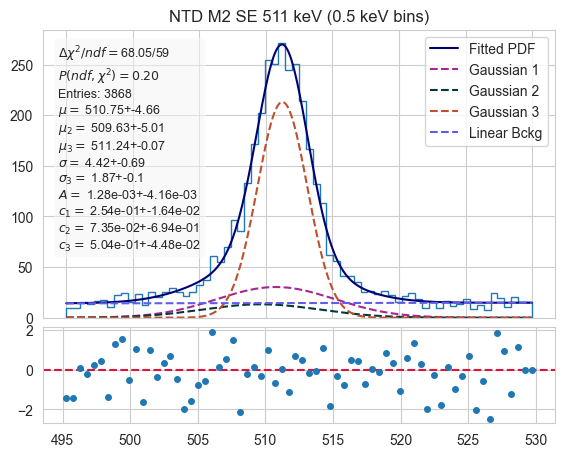

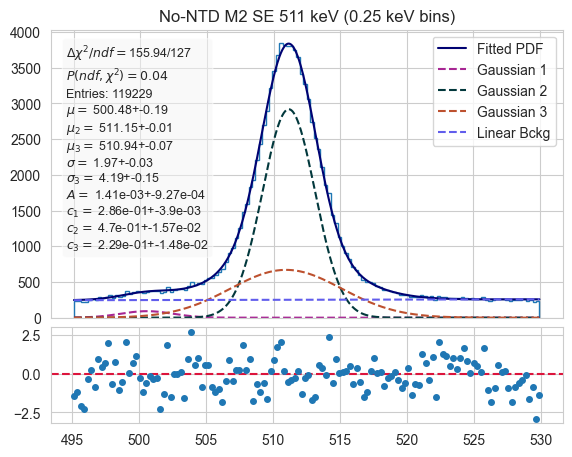

In [9]:
data = [i for i in NTD_511 if 495 <= i <= 530]

NTDmu, NTDmu_err, NTDmu2, NTDmu2_err, NTDmu3, NTDmu3_err, NTDsigma, NTDsigma_err, NTDsigma3, NTDsigma3_err = Minimizer(data, 'NTD M2 SE 511 keV (0.5 keV bins)', [511,  500, 525, 2,2, 0.033, 0.3, 0.3, 0.3], 2*int(max(data) - min(data)))

dataNoNTD = [i for i in noNTD_511 if 495 <= i <= 530]

noNTDmu, noNTDmu_err, noNTDmu2, noNTDmu2_err, noNTDmu3, noNTDmu3_err, noNTDsigma, noNTDsigma_err, noNTDsigma3, noNTDsigma3_err = Minimizer(dataNoNTD, 'No-NTD M2 SE 511 keV (0.25 keV bins)', [511,  505, 518, 2,2, 0.033, 0.3, 0.3, 0.3], 4*int(max(dataNoNTD) - min(dataNoNTD)))

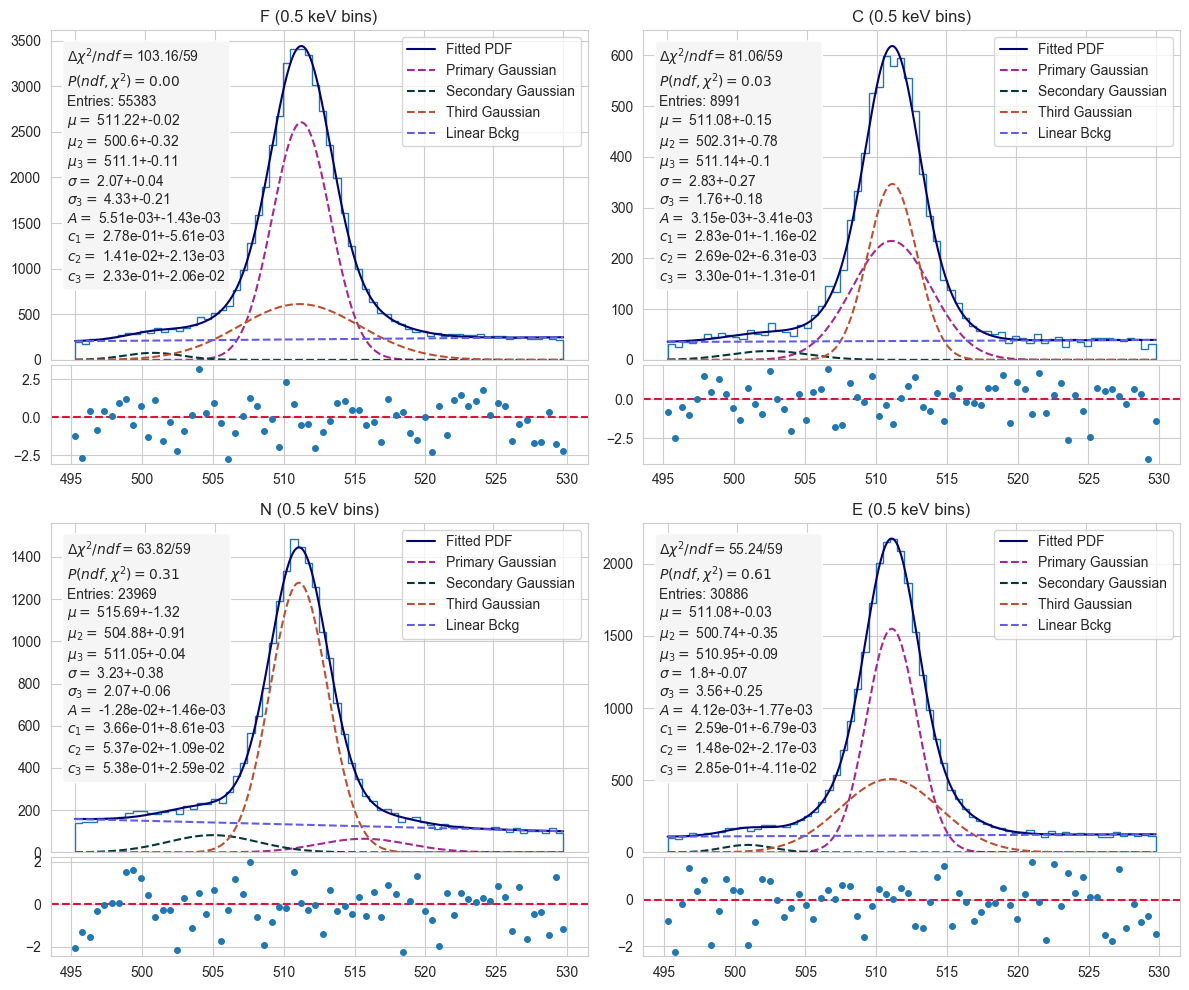

In [10]:
F_2100, F_511 = PrimarySecondarySplit(F)
C_2100, C_511 = PrimarySecondarySplit(C)
N_2100, N_511 = PrimarySecondarySplit(N)
E_2100, E_511 = PrimarySecondarySplit(E)

F_511_cut = [i for i in F_511 if 495 <= i <= 530]
C_511_cut = [i for i in C_511 if 495 <= i <= 530]
N_511_cut = [i for i in N_511 if 495 <= i <= 530]
E_511_cut = [i for i in E_511 if 495 <= i <= 530]

arr=[F_511_cut, C_511_cut, N_511_cut, E_511_cut]

topologies = ['F', 'C', 'N', 'E']

Fintial = [511,  505, 518, 2,2, 0.033, 0.1, 0.1, 0.1]
Cinitial = [511,  498, 520, 2,2, 0.033, 0.3, 0.3, 0.3]
Ninitial = [511,  500, 520, 2,2, 0.033, 0.3, 0.3, 0.3]
Eintial = [511,  504, 520, 2,2, 0.033, 0.1, 0.1, 0.1]

initial_parms = [Fintial, Cinitial, Ninitial, Eintial]


df = MinimizerTopology(arr, initial_parms,topologies)

In [11]:
def ExpectedVals(total_dataframe, dataframe):
        weights = [(((len(total_dataframe[total_dataframe['Dataset']==3801]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3801]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3802]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3802]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3803]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3803]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3804]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3804]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3805]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3805]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3806]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3806]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3807]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3807]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3808]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3808]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3809]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3809]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3810]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3810]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3811]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3811]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3812]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3812]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3813]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3813]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3814]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3814]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3815]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3815]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3816]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3816]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3817]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3817]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3818]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3818]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3819]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3819]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3820]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3820]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3821]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3821]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3822]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3822]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3823]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3823]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3824]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3824]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3825]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3825]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3826]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3826]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3827]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3827]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3828]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3828]))/len(dataframe))*100),
                   ]
        
        df_bias = pd.read_csv('Dataset-Info-ResBias/M2SE511_bias_all.txt', sep=',', names=['Dataset', 'Bias', 'Bias_err'], header=None)
        df_res = pd.read_csv('Dataset-Info-ResBias/M2SE511_reso_all.txt', sep=',', names=['Dataset', 'Res', 'Res_err'], header=None)
        
        mean_bias = 0
        sigma_res = 0
        
        for i in range(len(weights)):
                mean_bias += weights[i]*df_bias.iloc[i+1,1]
                sigma_res += weights[i]*df_res.iloc[i+1,1]
                
        average_means_bias = mean_bias/sum(weights)
        average_sigma_res = sigma_res/sum(weights)
        
        mean_bias_err = 0
        sigma_res_err = 0
        
        for i in range(len(weights)):
                mean_bias_err += (weights[i]*df_bias.iloc[i+1,2])**2
                sigma_res_err += (weights[i]*df_res.iloc[i+1,2])**2
        
        actual_mean_err = 1/sum(weights)*np.sqrt(mean_bias_err)
        actual_sigma_err = 1/sum(weights)*np.sqrt(sigma_res_err)
        
        
        return average_means_bias, (average_sigma_res/2.355), actual_mean_err, actual_sigma_err*(1/2.355)

In [12]:
mean_bias, sigma, meanerr, sigmaerr = ExpectedVals(dataframe_reduced_single, dataframe_reduced_single)

Text(0.5, 1.0, 'M2 Single 511 keV Standard Devs')

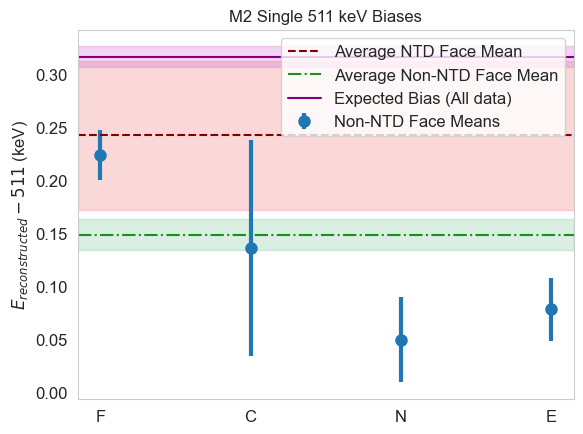

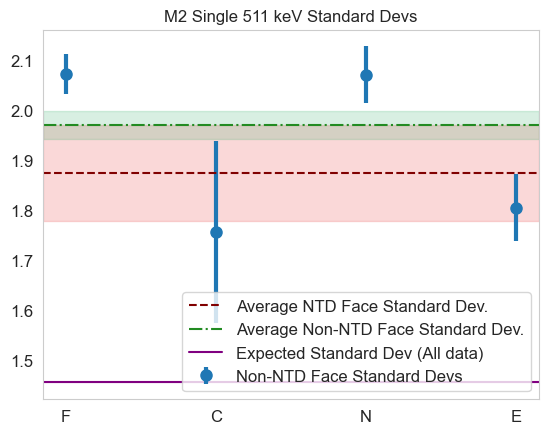

In [13]:
plt.figure()
topologymeans = [df['Means'][0], df['Means3'][1], df['Means3'][2], df['Means'][3]]
topologymeanerrors = [df['Meanserr'][0], df['Means3err'][1], df['Means3err'][2], df['Meanserr'][3]]

plt.errorbar(topologies, np.asarray(topologymeans)-511, yerr=topologymeanerrors, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
# plt.errorbar(xNonNTD-0.13, topologymeans, yerr=asymmetric_errormu, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
# plt.errorbar(xNTD+0.13, NTDmeans, yerr=ass_errNTD, fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Means')

plt.axhspan(NTDmu3-511 - NTDmu3_err, NTDmu3-511 + NTDmu3_err, color='lightcoral', alpha=0.3)
plt.axhline(NTDmu3-511, color='maroon', linestyle='--', label='Average NTD Face Mean')

plt.axhspan(noNTDmu2-511-noNTDmu2_err, noNTDmu2-511+noNTDmu2_err, color='mediumseagreen', alpha=0.2)
plt.axhline(noNTDmu2-511, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Mean')

plt.axhspan(mean_bias + meanerr, mean_bias - meanerr, color='orchid', alpha=0.3)
plt.axhline(mean_bias, color='purple', linestyle='-', label='Expected Bias (All data)')

plt.legend(fontsize=12, loc='upper right')

plt.xticks(np.arange(len(topologies)), topologies, fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M2 Single 511 keV Biases')
plt.ylabel(r'$E_{reconstructed}-511$ (keV)', fontsize=12)

plt.figure()
topologysigmas = [df['Sigmas'][0], df['Sigmas3'][1], df['Sigmas3'][2], df['Sigmas'][3]]
topologysigmaerrors = [df['Sigmaserr'][0], df['Sigmas3err'][1], df['Sigmas3err'][2], df['Sigmaserr'][3]]

plt.errorbar(topologies, topologysigmas, yerr=topologysigmaerrors, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Standard Devs')
# plt.errorbar(xNonNTD-0.13, topologymeans, yerr=asymmetric_errormu, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
# plt.errorbar(xNTD+0.13, NTDmeans, yerr=ass_errNTD, fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Means')

plt.axhspan(NTDsigma3 + NTDsigma3_err, NTDsigma3 - NTDsigma3_err, color='lightcoral', alpha=0.3)
plt.axhline(NTDsigma3, color='maroon', linestyle='--', label='Average NTD Face Standard Dev.')

plt.axhspan(noNTDsigma-noNTDsigma_err, noNTDsigma+noNTDsigma_err, color='mediumseagreen', alpha=0.2)
plt.axhline(noNTDsigma, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Standard Dev.')

plt.axhspan(sigma + sigmaerr, sigma - sigmaerr, color='orchid', alpha=0.3)
plt.axhline(sigma, color='purple', linestyle='-', label='Expected Standard Dev (All data)')

plt.legend(fontsize=12, loc='lower right')

plt.xticks(np.arange(len(topologies)), topologies, fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M2 Single 511 keV Standard Devs')

In [29]:
for i in range(len(topologymeans)):
    print(str(topologymeans[i]-511) + '+-' + str(topologymeanerrors[i]))
    print(str(topologysigmas[i]) + '+-' + str(topologysigmaerrors[i]))
    
print(mean_bias)
print(meanerr)
print(sigma)
print(sigmaerr)

0.22376422516822458+-0.02350718547887709
2.0720138061194775+-0.03982014177787607
0.13585645421039771+-0.10187582838909748
1.7558345511056577+-0.18234664529369682
0.04918455094798446+-0.0401655345377776
2.0705632900595385+-0.05634581463299515
0.07818172452118688+-0.02963480779095562
1.8047972665350671+-0.06760162043502027
0.31657142857142845
0.009582083621562286
1.4551471034273578
0.0002188831064852855
